# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. A penalty is added to mean squared error to prevent overfitting when the model is too complex. The bigger the mean sqaured error, the bigger the penalty that is added to it, which increases the number of model parameters. This leads to better generalization and less bias.
2. Regularization adds a penalty term to the loss function to explore and manage the bias-variance trade-off. This reduces overfitting by controlling the coefficient sizes.
3. LASSO shrinks coefficients to 0 when only some features seem important and the model needs to be simpler. Ridge regression also lowers coefficient values but doesn't fully eliminate this to keep all the features. Ridge is used when each feature has smaller efffects and multicollinearity is high.
4. We typically scale variables by standardizing them for use in regularized regression. We do this to make sure that all features are treated equally and no one variable heavily affects or biases another or the model.
5. The penalty is typically selected using cross-validation. We use the K-fold cross-validation test.
6. In the cross-validation, we do not include the penalty term in evaluating the cross validated MSE. The point of it is to estimate the general error of the model and the penalty is apart of the training. 

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [35]:
# Question 1

import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import matplotlib.pyplot as plt

df = pd.read_csv('data/cars_hw.csv')

df['Age'] = 2023 - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
print(feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
print(X_scaled[:5])

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
[[ 0.12469203 -0.01309242 -0.13767332 -0.09428148 -0.22006223 -0.29461484
  -0.25878908 -0.27287434 -0.34864502]
 [-0.87233418  0.34185769 -0.79131562 -0.60247795  0.12127635 -0.6612157
  -0.6824487  -0.50254773 -0.06587084]
 [-0.49351672 -0.72299265 -0.60062321 -0.69953772 -0.7451985  -0.58186282
  -0.65417    -0.69886449 -0.68708342]
 [-0.24165541 -0.01309242 -0.43473174 -0.31121766 -0.22006223 -0.49229487
  -0.46009501 -0.39372132 -0.34864502]
 [-0.67457793 -0.01309242 -0.70058282 -0.56757691 -0.22006223 -0.62706416
  -0.64025284 -0.53652941 -0.34864502]]


In [36]:
# Question 2

lr = LinearRegression()
lr.fit(X_scaled, y)

interaction_idx = list(feature_names).index('Mileage_Run Age')
interaction_coef = lr.coef_[interaction_idx]
print(f"Interaction Coefficient (Linear): {interaction_coef}")
print("The sign is negative.")

Interaction Coefficient (Linear): -1066665.354037465
The sign is negative.


In [37]:
# Question 3
alphas = np.logspace(1, 3, 20)
coefs_path = []

lasso_cv = LassoCV(alphas=alphas, cv=20, random_state=42)
lasso_cv.fit(X_scaled, y)
print(f"Optimal Alpha: {lasso_cv.alpha_}")

# Train Lasso for each alpha to get the path
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs_path.append(lasso.coef_)
print(alphas)
print(coefs_path)

Optimal Alpha: 483.2930238571752


/Users/pavigupta/Documents/Machine Learning I/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.562e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/pavigupta/Documents/Machine Learning I/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.273e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Users/pavigupta/Documents/Machine Learning I/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the n

[  10.           12.74274986   16.23776739   20.69138081   26.36650899
   33.59818286   42.81332399   54.55594781   69.51927962   88.58667904
  112.88378917  143.84498883  183.29807108  233.57214691  297.63514416
  379.26901907  483.29302386  615.84821107  784.75997035 1000.        ]
[array([  550872.8013    ,  -146166.51357843,  -119687.73180656,
       -1040455.96478735,   120408.12770906,   -65508.57889158,
         254049.03179299,   427907.29931985,   -81576.96312532]), array([  548539.90948636,  -142801.0421546 ,  -119412.04291485,
       -1033221.15303572,   109356.51428531,   -65623.83930718,
         253499.39401904,   423228.65316903,   -73891.28195493]), array([  545557.07715706,  -138511.28141283,  -119033.00029951,
       -1024011.22363724,    95278.97595968,   -65777.20880187,
         252778.89066522,   417289.88976567,   -64109.12145814]), array([  541736.39859452,  -133043.46258228,  -118492.13690547,
       -1012299.04469149,    77356.04537827,   -65985.59278941,
    

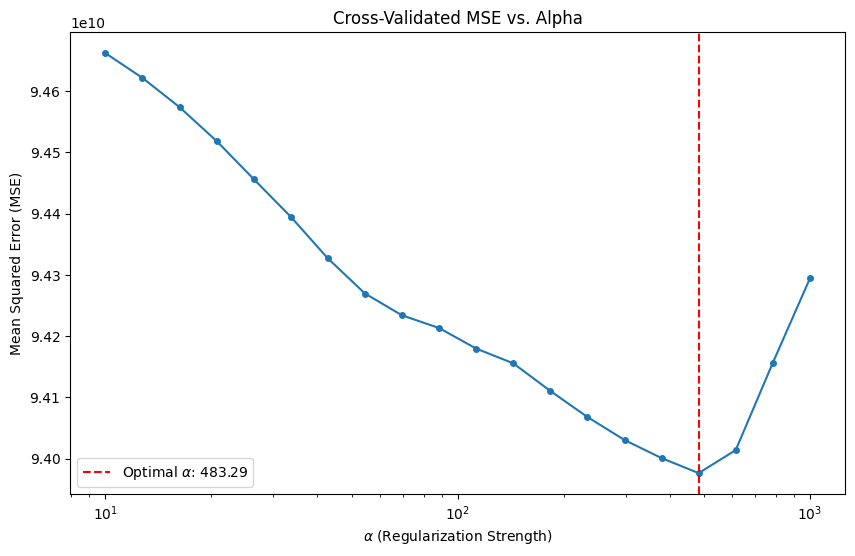

In [38]:
# Question 4
plt.figure(figsize=(10, 6))

mse_path_mean = lasso_cv.mse_path_.mean(axis=1)

plt.plot(lasso_cv.alphas_, mse_path_mean, marker='o', markersize=4)

plt.xscale('log')

plt.axvline(lasso_cv.alpha_, linestyle='--', color='r', 
            label=rf'Optimal $\alpha$: {lasso_cv.alpha_:.2f}')

plt.xlabel(r'$\alpha$ (Regularization Strength)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validated MSE vs. Alpha')
plt.legend()
plt.show()

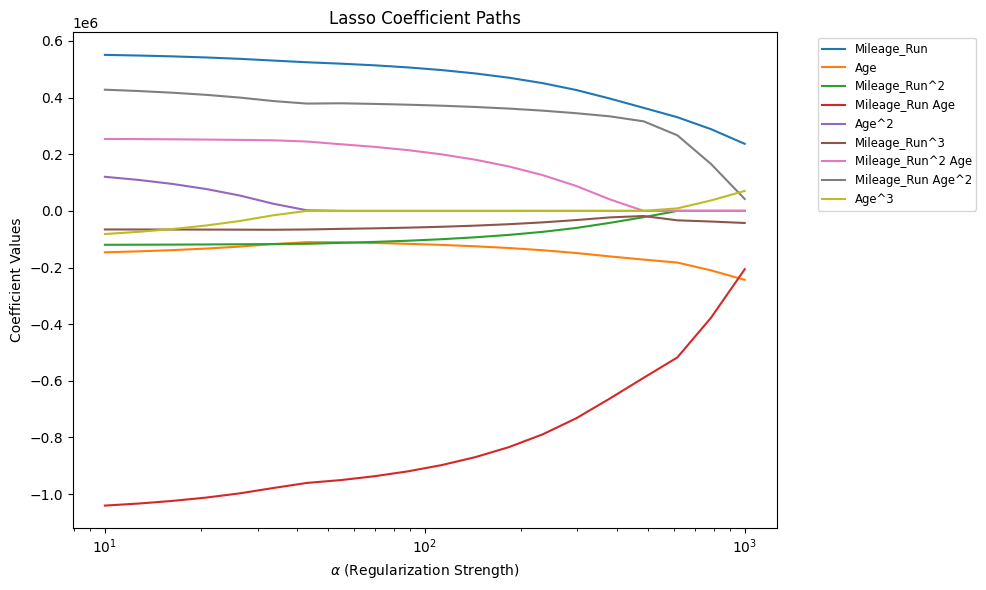

In [39]:
# Question 5
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs_path)
plt.xscale('log')
plt.xlabel(r'$\alpha$ (Regularization Strength)')
plt.ylabel('Coefficient Values')
plt.title('Lasso Coefficient Paths')
plt.legend(feature_names, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?
There are 7 selected feature: Mileage_Run, Age, Mileage_Run^2, Mileage_Run Age, Mileage_Run^2. Mileage_Run Age^2, and Age^3. There are 2 features set to zero, so the proportion set to 0 is 2/9, or 22%.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

The coefficient of Age increased in magnitude. This could be a result of the change of another feature. The change in sign for Age^3 does make more sense. This likely means that regularizationed changed the curve for age in order to get a better fit. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [40]:
# Question 1

df =pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
y = df['DEATH_EVENT']
print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [41]:
cont_cols = ['age', 'ejection_fraction', 'serum_creatinine']
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(df[cont_cols])
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

cat_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_interact = poly_cat.fit_transform(df[cat_cols])

X = np.hstack((X_cont_scaled, X_cat_interact))
all_features = list(poly_cont.get_feature_names_out(cont_cols)) + \
               list(poly_cat.get_feature_names_out(cat_cols))

In [42]:
# Question 2

lr = LinearRegression()
lr.fit(X, y)

coef_summary = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lr.coef_
})

print(coef_summary)

risk_factors = ['diabetes', 'high_blood_pressure', 'smoking']
print("\nRisk Factor Coefficients in OLS:")
print(coef_summary[coef_summary['Feature'].isin(risk_factors)])

                                   Feature  Coefficient
0                                      age     1.539156
1                        ejection_fraction    -2.192494
2                         serum_creatinine    -0.853588
3                                    age^2    -3.678654
4                    age ejection_fraction    -0.600918
5                     age serum_creatinine     1.841563
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
9                                    age^3     1.993135
10                 age^2 ejection_fraction     0.908026
11                  age^2 serum_creatinine    -0.697522
12                 age ejection_fraction^2    -0.081206
13  age ejection_fraction serum_creatinine    -1.577665
14                  age serum_creatinine^2     1.284099
15                     ejection_fraction^3    -1.250341
16    ejection_fraction^2 serum_creatinine    -1

Yes, there are sign patterns that seem counterintuitive. This is because of multicollinearity, where the features are highly correlated with each other. The inclusion of higher-order powers or interactions might create a contradition because of its complexity and to capture non-linear risks.

In [43]:
# Question 3

alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=42)
lasso_cv.fit(X, y)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+05])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",20
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


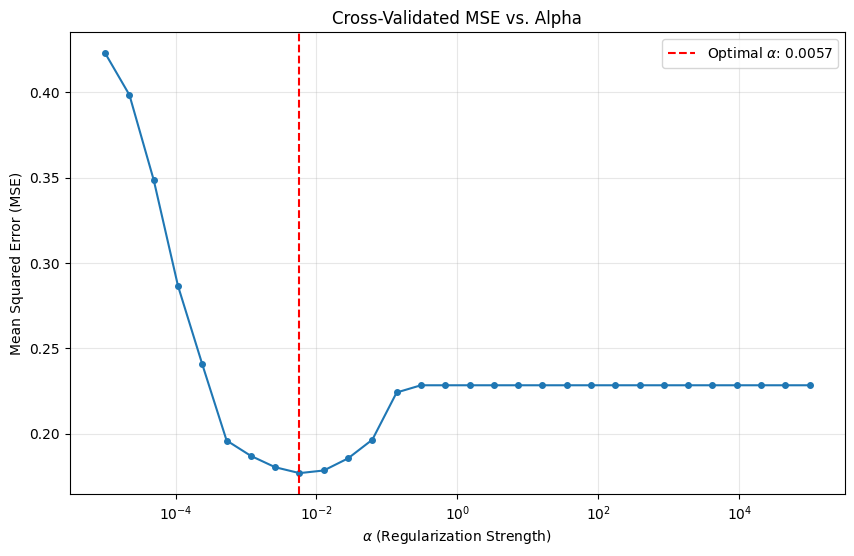

In [44]:
# Question 4

plt.figure(figsize=(10, 6))

mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
plt.plot(lasso_cv.alphas_, mse_mean, marker='o', markersize=4, linestyle='-')
plt.xscale('log')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', 
            label=rf'Optimal $\alpha$: {lasso_cv.alpha_:.4f}')

plt.xlabel(r'$\alpha$ (Regularization Strength)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validated MSE vs. Alpha')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

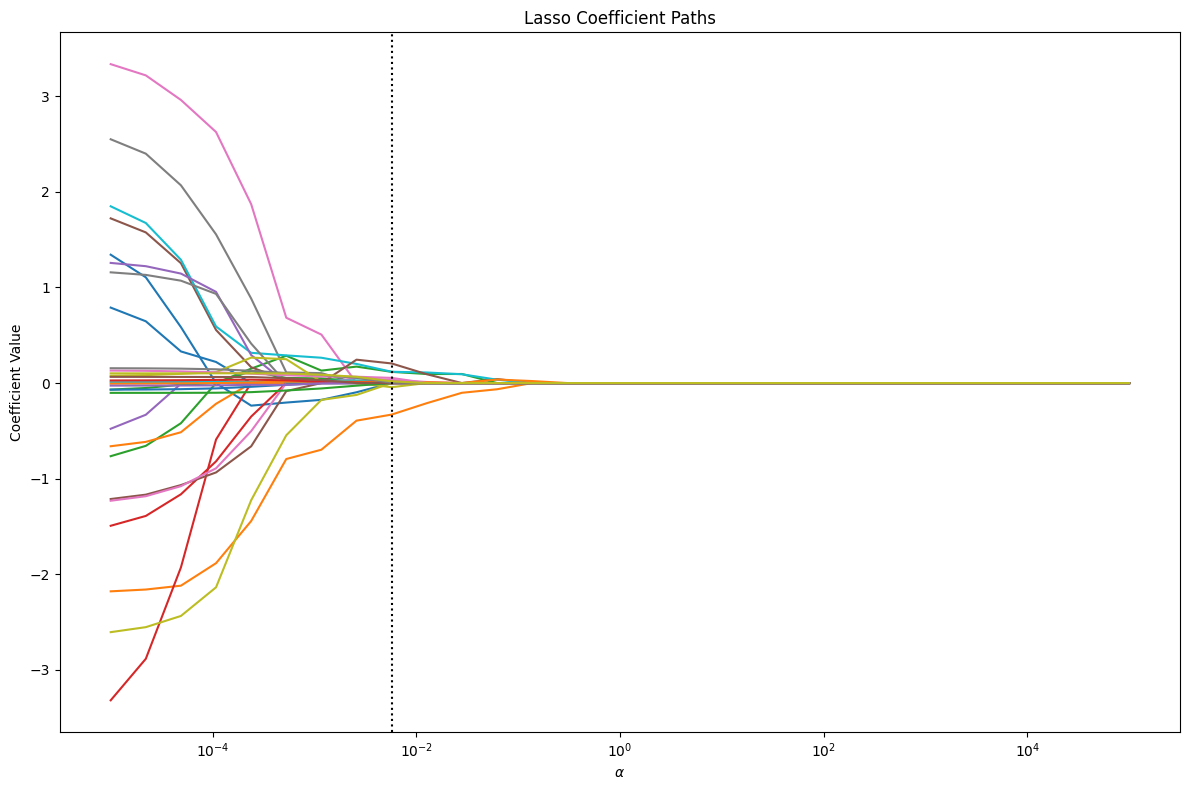

In [45]:
# Question 5

lasso_coefs_path = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=100000)
    l.fit(X, y)
    lasso_coefs_path.append(l.coef_)

lasso_coefs_path = np.array(lasso_coefs_path)

plt.figure(figsize=(12, 8))

for i in range(len(all_features)):
    label = all_features[i] if i < 12 else None 
    plt.plot(alphas, lasso_coefs_path[:, i], label=label)

plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.axvline(lasso_cv.alpha_, color='black', linestyle=':', label='Optimal Alpha')
plt.tight_layout()
plt.show()

Question 6: Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

12 non-zero features were selected, while 59% of the features were set to zero. The magnitude of the coefficients of 'anaemia' and 'high_blood_pressure' increased. Many features changed signs as well. The sign patterns for the Lasso seem to make more sense. OLS has a higher variance because it tries to minimize the training error even though it has a lot of parameters. Lasso has a more controlled bias since it shrinks its coefficients.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![HW4Q4.jpg](/HW4Q4.JPG)

^in case the image above doesn't load I have included it in my GitHub